# Selección de la ventana de lluvia — figuras y tabla

**Tesis MSc — Oscar I. Sánchez P. | Capítulo 5**

Grafica los resultados de `mc_window_search.py`: el barrido de las 581 combinaciones de lluvia de corto plazo (STR, 1–7 días) y largo plazo (LTR, 8–90 días), cada una con 100 corridas Monte Carlo del paquete A.

## El problema que resuelve esta figura

El máximo del barrido está en STR=1, LTR=9 con una mediana de AUROC de 0.9519. La décima mejor combinación tiene 0.9502. La diferencia entre ambas es **0.0017**, mientras que la desviación estándar del AUROC entre las 100 corridas de una sola combinación es **0.011**, unas diez veces mayor.

Es decir: las combinaciones de la cabeza del ranking **no se distinguen entre sí**. Quedarse con el argmax es quedarse con ruido de muestreo.

La figura está diseñada para mostrar exactamente eso y para justificar una elección basada en el proceso y no en el tercer decimal:

- **Panel (a)** — mapa de calor de la mediana del AUROC, con el contorno de la **región estadísticamente equivalente al máximo** (regla de un error estándar), el óptimo numérico marcado con un círculo y la combinación seleccionada con un cuadro.
- **Panel (b)** — mapa de calor de la desviación estándar entre corridas, que es la escala del ruido.
- **Panel (c)** — perfil de la mediana del AUROC frente a LTR, una línea por cada STR, con la banda intercuartil de las 100 corridas para STR=1. Este panel es el que hace el argumento: la curva es plana y la banda de incertidumbre se traga las diferencias.

## La regla de un error estándar

Es un criterio estándar en selección de modelos (Breiman et al., 1984; Hastie et al., 2009): en lugar del máximo, se retiene el conjunto de configuraciones cuyo desempeño cae dentro de un error estándar del mejor, y dentro de ese conjunto se elige la más simple o la más interpretable. Aquí:

$$\mathrm{SE} = \frac{\sigma_{\mathrm{AUROC}}}{\sqrt{n_{\mathrm{runs}}}} = \frac{0.011}{\sqrt{100}} \approx 0.0011$$

> **Nota**: las 100 corridas comparten los mismos eventos (solo cambian las ausencias), así que no son del todo independientes y el SE real es **mayor** que este. Eso hace el argumento más fuerte, no más débil: la región de equivalencia es aún más amplia.

## 1. Librerías y configuración

In [13]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

ANCHO = 8.46           # pulgadas = 467 pt, el \textwidth de tu documento
ALTO  = ANCHO * 0.83   # conserva la proporción actual (9.6/11.5)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ------------------------------------------------------------------ rutas
OUT_DIR      = '/home/oisanchezp/Thesis/src/05_Chapter/Montecarlo/'
PATH_SUMMARY = os.path.join(OUT_DIR, 'window_search_summary.csv')
PATH_RAW     = os.path.join(OUT_DIR, 'window_search_raw.csv')   # opcional
FIG_DIR      = '00Figuras/05Seccion'
FIG_NAME     = 'fig_window_search'

# -------------------------------------------------------------- selección
T_SEL, P_SEL = 1, 30      # la combinación que se adopta en la tesis
K_SE         = 1.0        # ancho de la banda de equivalencia (en errores estándar)

os.makedirs(FIG_DIR, exist_ok=True)

## 2. Carga y banda de equivalencia

Se calcula el error estándar de la mejor combinación y se marca qué combinaciones caen dentro de `K_SE` errores estándar de ella.

In [14]:
summary = pd.read_csv(PATH_SUMMARY)
print(f'Combinaciones evaluadas: {len(summary)}')
print(f'Corridas por combinacion: {int(summary["count"].median())}')

n_runs = float(summary['count'].median())

i_best   = summary['median'].idxmax()
best     = summary.loc[i_best]
se_best  = float(best['std']) / np.sqrt(n_runs)
umbral   = float(best['median']) - K_SE * se_best

summary['dentro_banda'] = summary['median'] >= umbral
summary['delta'] = float(best['median']) - summary['median']

sel = summary[(summary.T_days == T_SEL) & (summary.P_days == P_SEL)].iloc[0]

print(f'\nOptimo numerico     : STR={int(best.T_days)} d, LTR={int(best.P_days)} d  '
      f'| mediana AUROC = {best["median"]:.4f}  | sd = {best["std"]:.4f}')
print(f'Error estandar (SE) : {se_best:.5f}   (sd / sqrt({n_runs:.0f}))')
print(f'Umbral de equivalencia (mejor - {K_SE:g} SE): {umbral:.4f}')
print(f'Combinaciones dentro de la banda: {int(summary.dentro_banda.sum())} '
      f'de {len(summary)}')

print(f'\nSeleccion adoptada  : STR={T_SEL} d, LTR={P_SEL} d  '
      f'| mediana AUROC = {sel["median"]:.4f}')
print(f'  diferencia con el optimo : {sel["delta"]:.4f}  '
      f'({sel["delta"]/se_best:.2f} SE)')
print(f'  dentro de la banda        : {bool(sel.dentro_banda)}')

# LTR dentro de la banda, para ver si forman un grupo compacto
ltr_banda = sorted(summary.loc[summary.dentro_banda, 'P_days'].unique())
print(f'\nLTR dentro de la banda: {ltr_banda}')

Combinaciones evaluadas: 581
Corridas por combinacion: 100

Optimo numerico     : STR=1 d, LTR=9 d  | mediana AUROC = 0.9519  | sd = 0.0115
Error estandar (SE) : 0.00115   (sd / sqrt(100))
Umbral de equivalencia (mejor - 1 SE): 0.9508
Combinaciones dentro de la banda: 7 de 581

Seleccion adoptada  : STR=1 d, LTR=30 d  | mediana AUROC = 0.9510
  diferencia con el optimo : 0.0010  (0.82 SE)
  dentro de la banda        : True

LTR dentro de la banda: [9, 10, 17, 30, 31, 32, 33]


## 3. Banda intercuartil de las corridas (opcional)

Si existe `window_search_raw.csv`, se calculan los cuartiles del AUROC de las 100 corridas de cada combinación. La banda intercuartil es una medida más honesta de la incertidumbre que la desviación estándar y es la que se dibuja en el panel (c).

In [15]:
raw = None
if os.path.exists(PATH_RAW):
    raw = pd.read_csv(PATH_RAW)
    q = (raw.groupby(['T_days', 'P_days'])['auc']
         .quantile([0.25, 0.75]).unstack())
    q.columns = ['q25', 'q75']
    summary = summary.merge(q.reset_index(), on=['T_days', 'P_days'], how='left')
    print(f'Raw cargado: {len(raw):,} filas. Cuartiles calculados.')
else:
    # sin raw, se aproxima la banda con +- 1 sd
    summary['q25'] = summary['median'] - summary['std']
    summary['q75'] = summary['median'] + summary['std']
    print('No se encontro el raw: la banda del panel (c) usa +- 1 sd.')

Raw cargado: 58,100 filas. Cuartiles calculados.


## 4. Figura de tres paneles

Guardado en 00Figuras/05Seccion/fig_window_search


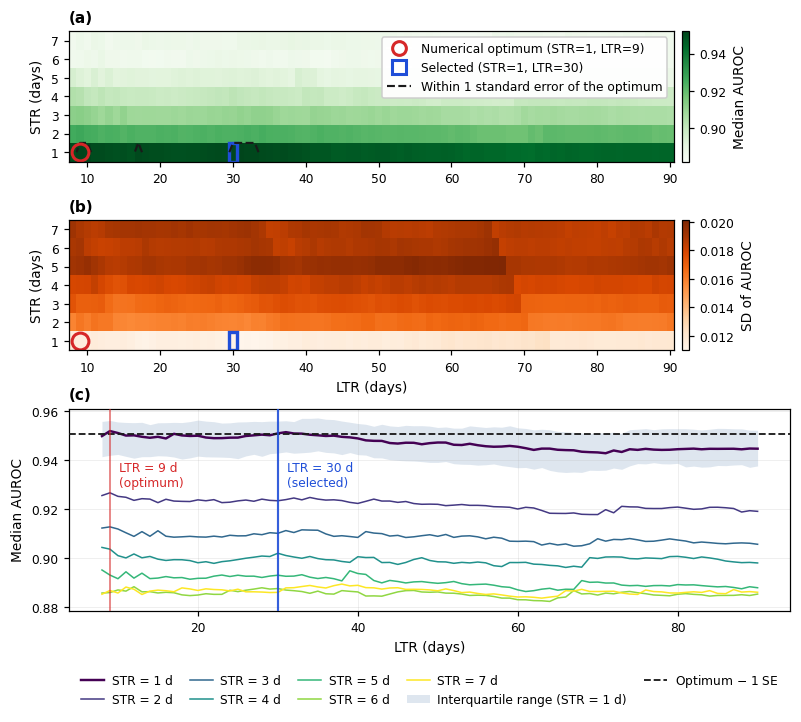

In [17]:
piv_med   = summary.pivot(index='T_days', columns='P_days', values='median')
piv_std   = summary.pivot(index='T_days', columns='P_days', values='std')
piv_banda = summary.pivot(index='T_days', columns='P_days',
                          values='dentro_banda').astype(float)

Pv = piv_med.columns.to_numpy(dtype=float)
Tv = piv_med.index.to_numpy(dtype=float)
ext = [Pv.min() - 0.5, Pv.max() + 0.5, Tv.min() - 0.5, Tv.max() + 0.5]

fig = plt.figure(figsize=(ANCHO, ALTO))
gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.0, 1.55], 
                      hspace=0.38, bottom=0.13)

# ---------------------------------------------------------------- (a)
ax = fig.add_subplot(gs[0])
im = ax.imshow(piv_med.to_numpy(), origin='lower', aspect='auto',
               extent=ext, cmap='Greens')
cb = fig.colorbar(im, ax=ax, pad=0.012)
cb.set_label('Median AUROC')

# contorno de la region estadisticamente equivalente al maximo
ax.contour(Pv, Tv, piv_banda.to_numpy(), levels=[0.5],
           colors='#1a1a1a', linewidths=1.4, linestyles='--')

# optimo numerico y seleccion adoptada
ax.plot(best.P_days, best.T_days, 'o', mfc='none', mec='#d62728',
        mew=2.0, ms=11)
ax.add_patch(Rectangle((P_SEL - 0.5, T_SEL - 0.5), 1, 1,
                       fill=False, ec='#1f4ed8', lw=2.2))

ax.set_ylabel('STR (days)')
ax.set_yticks(Tv)
#ax.set_title('(a)  Median AUROC over 100 Monte Carlo runs', loc='left')
ax.set_title('(a)', loc='left')
ax.legend(handles=[
    Line2D([], [], marker='o', color='w', mec='#d62728', mew=2, ms=9,
           label=f'Numerical optimum (STR={int(best.T_days)}, LTR={int(best.P_days)})'),
    Line2D([], [], marker='s', color='w', mec='#1f4ed8', mew=2, ms=9,
           label=f'Selected (STR={T_SEL}, LTR={P_SEL})'),
    Line2D([], [], color='#1a1a1a', ls='--', lw=1.4,
           label=f'Within {K_SE:g} standard error of the optimum'),
], loc='upper right', fontsize=8, framealpha=0.95, ncol=1)

# ---------------------------------------------------------------- (b)
ax = fig.add_subplot(gs[1])
im = ax.imshow(piv_std.to_numpy(), origin='lower', aspect='auto',
               extent=ext, cmap='Oranges')
cb = fig.colorbar(im, ax=ax, pad=0.012)
cb.set_label('SD of AUROC')
ax.plot(best.P_days, best.T_days, 'o', mfc='none', mec='#d62728', mew=2.0, ms=11)
ax.add_patch(Rectangle((P_SEL - 0.5, T_SEL - 0.5), 1, 1,
                       fill=False, ec='#1f4ed8', lw=2.2))
ax.set_ylabel('STR (days)')
ax.set_xlabel('LTR (days)')
ax.set_yticks(Tv)
ax.set_title('(b)', loc='left')
#ax.set_title('(b)  Spread of the AUROC between runs', loc='left')

# ---------------------------------------------------------------- (c)
ax = fig.add_subplot(gs[2])
cmap = plt.get_cmap('viridis')
for k, t in enumerate(Tv):
    sub = summary[summary.T_days == t].sort_values('P_days')
    ax.plot(sub.P_days, sub['median'], lw=1.6 if t == T_SEL else 1.0,
            color=cmap(k / max(len(Tv) - 1, 1)),
            label=f'STR = {int(t)} d', zorder=3 if t == T_SEL else 2)

sub1 = summary[summary.T_days == T_SEL].sort_values('P_days')
ax.fill_between(sub1.P_days, sub1.q25, sub1.q75, color='#4c78a8',
                alpha=0.18, lw=0, zorder=1,
                label=f'Interquartile range (STR = {T_SEL} d)')

ax.axhline(umbral, color='#1a1a1a', ls='--', lw=1.2, zorder=4,
           label=f'Optimum $-$ {K_SE:g} SE')
ax.axvline(best.P_days, color='#d62728', lw=1.0, alpha=0.7, zorder=4)
ax.axvline(P_SEL, color='#1f4ed8', lw=1.4, alpha=0.9, zorder=4)
ax.annotate(f'LTR = {int(best.P_days)} d\n(optimum)', xy=(best.P_days, umbral),
            xytext=(6, -34), textcoords='offset points',
            fontsize=8, color='#d62728')
ax.annotate(f'LTR = {P_SEL} d\n(selected)', xy=(P_SEL, umbral),
            xytext=(6, -34), textcoords='offset points',
            fontsize=8, color='#1f4ed8')

ax.set_xlabel('LTR (days)')
ax.set_ylabel('Median AUROC')
ax.grid(alpha=0.25, lw=0.5)

#ax.set_title('(c)  Performance profile along the long-term window', loc='left')
ax.set_title('(c)', loc='left')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.28),
          ncol=5, fontsize=8, frameon=False,
          columnspacing=1.4, handlelength=1.9, handletextpad=0.6,
          borderaxespad=0.0)


fig.savefig(os.path.join(FIG_DIR, f'{FIG_NAME}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, f'{FIG_NAME}.png'), dpi=300, bbox_inches='tight')
print('Guardado en', os.path.join(FIG_DIR, FIG_NAME))
plt.show()

## 5. Tabla del top 10 para la tesis

Con la diferencia respecto al óptimo expresada **en errores estándar**, que es la columna que hace visible el argumento: todas las combinaciones de la cabeza están a una fracción de SE unas de otras.

In [7]:
top = (summary.sort_values('median', ascending=False).head(10).copy()
       .reset_index(drop=True))
top['delta_SE'] = top['delta'] / se_best
top['sel'] = np.where((top.T_days == T_SEL) & (top.P_days == P_SEL), '<--', '')

tabla = top[['T_days', 'P_days', 'median', 'std', 'delta', 'delta_SE',
             'dentro_banda', 'sel']].round(4)
tabla.columns = ['STR (d)', 'LTR (d)', 'Median AUROC', 'SD',
                 'Delta', 'Delta (SE)', 'Within band', '']
print(tabla.to_string(index=False))
tabla.to_csv(os.path.join(OUT_DIR, 'window_search_top10.csv'), index=False)

# --- versión LaTeX lista para pegar -----------------------------------
print('\n' + '=' * 60 + '\nLaTeX:\n')
print('\\begin{tabular}{cccccc}')
print('\\hline')
print('STR (d) & LTR (d) & Median AUROC & SD & $\\Delta$ & $\\Delta$/SE \\\\')
print('\\hline')
for _, r in top.iterrows():
    mark = '\\textbf{' if r['sel'] else ''
    end  = '}' if r['sel'] else ''
    print(f"{mark}{int(r.T_days)}{end} & {mark}{int(r.P_days)}{end} & "
          f"{mark}{r['median']:.4f}{end} & {r['std']:.4f} & "
          f"{r['delta']:.4f} & {r['delta_SE']:.2f} \\\\")
print('\\hline')
print('\\end{tabular}')

 STR (d)  LTR (d)  Median AUROC     SD  Delta  Delta (SE)  Within band    
       1        9        0.9519 0.0115 0.0000      0.0000         True    
       1       31        0.9515 0.0110 0.0005      0.3927         True    
       1       10        0.9511 0.0115 0.0008      0.7034         True    
       1       30        0.9510 0.0112 0.0010      0.8247         True <--
       1       32        0.9509 0.0110 0.0010      0.8639         True    
       1       33        0.9508 0.0110 0.0011      0.9232         True    
       1       17        0.9508 0.0112 0.0011      0.9794         True    
       1       28        0.9504 0.0113 0.0015      1.2729        False    
       1       34        0.9504 0.0111 0.0015      1.3071        False    
       1       29        0.9502 0.0112 0.0017      1.4972        False    

LaTeX:

\begin{tabular}{cccccc}
\hline
STR (d) & LTR (d) & Median AUROC & SD & $\Delta$ & $\Delta$/SE \\
\hline
1 & 9 & 0.9519 & 0.0115 & 0.0000 & 0.00 \\
1 & 31 & 0.9515 & 0

## 6. Cifras sueltas que hay que citar en el texto

In [8]:
rango_top10 = top['median'].max() - top['median'].min()

print(f'Mediana AUROC del optimo            : {best["median"]:.4f}')
print(f'Mediana AUROC de la seleccion       : {sel["median"]:.4f}')
print(f'Rango del top 10                    : {rango_top10:.4f}')
print(f'SD entre corridas (tipica)          : {summary["std"].median():.4f}')
print(f'Razon SD / rango del top 10         : {summary["std"].median()/rango_top10:.1f}x')
print(f'Combinaciones equivalentes al optimo: {int(summary.dentro_banda.sum())}')

# efecto del STR: cuanto cae el desempeno al alargar la ventana de disparo
perfil_t = summary.groupby('T_days')['median'].max()
print('\nMejor AUROC alcanzable por cada STR:')
print(perfil_t.round(4).to_string())
print(f'\nCaida de STR=1 a STR=7: {perfil_t.iloc[0] - perfil_t.iloc[-1]:.4f} '
      f'({(perfil_t.iloc[0]-perfil_t.iloc[-1])/se_best:.1f} SE)')

# agrupamiento de los LTR dentro de la banda
ltr_b = np.array(sorted(summary.loc[summary.dentro_banda &
                                    (summary.T_days == T_SEL), 'P_days']))
print(f'\nLTR dentro de la banda para STR={T_SEL}: {ltr_b.tolist()}')
if len(ltr_b):
    saltos = np.where(np.diff(ltr_b) > 1)[0]
    grupos = np.split(ltr_b, saltos + 1)
    print('Grupos contiguos:')
    for g in grupos:
        print(f'  {g.min()}-{g.max()} d  ({len(g)} combinaciones)')

Mediana AUROC del optimo            : 0.9519
Mediana AUROC de la seleccion       : 0.9510
Rango del top 10                    : 0.0017
SD entre corridas (tipica)          : 0.0180
Razon SD / rango del top 10         : 10.4x
Combinaciones equivalentes al optimo: 7

Mejor AUROC alcanzable por cada STR:
T_days
1    0.9519
2    0.9266
3    0.9127
4    0.9043
5    0.8951
6    0.8882
7    0.8893

Caida de STR=1 a STR=7: 0.0626 (54.3 SE)

LTR dentro de la banda para STR=1: [9, 10, 17, 30, 31, 32, 33]
Grupos contiguos:
  9-10 d  (2 combinaciones)
  17-17 d  (1 combinaciones)
  30-33 d  (4 combinaciones)


## 7. Texto de justificación para el capítulo

Va en la Sección 5.4.1 (Results — *Sampling designs and rainfall window selection*). Ajusta los números con lo que imprima la celda anterior.

```latex
\par The performance surface is remarkably flat (Fig.~\ref{fig:th-grid}). The
best combination, a one-day short-term window with a nine-day long-term window,
reached a median AUROC of 0.952, but the ten best combinations span only 0.002,
while the standard deviation of the AUROC across the 100 Monte Carlo runs of a
single combination is 0.011, about ten times larger. The combinations at the top
of the ranking therefore cannot be told apart from one another, and taking the
one with the highest median would amount to selecting sampling noise.

\par We did not take the maximum. Following the one-standard-error rule commonly
used in model selection \citep{breiman1984, hastie2009}, we retained the
combinations whose median AUROC lies within one standard error of the best, and
chose within that set on process grounds rather than on performance. Two features
of the surface guided the choice. The short-term window is unambiguous:
performance falls steadily as it grows from one to seven days, so a one-day
window is the best description of the triggering rainfall by a clear margin. The
long-term windows inside the band, in contrast, form a broad plateau centred
around 28 to 34 days, with an isolated point at nine days that has no neighbours
of comparable performance, which is what one expects from a local fluctuation
rather than from a real signal.

\par We therefore adopted a one-day short-term window and a 30-day long-term
window. Besides lying inside the statistically equivalent set and inside the
dominant plateau, this choice has two practical advantages. A nine-day window
sits in a no-man's land: it is too long to describe the rainfall that triggers a
failure and too short to describe the wetness of the soil that precedes it,
whereas 30 days is closer to the time over which the residual soils of the valley
retain moisture between storms. It also keeps the chapter internally consistent,
since the wet-condition filter applied to both classes
(Section~\ref{sec:th-sampling}) is defined over the same 30 days.
```

**Claves de bibliografía nuevas:**

```bibtex
@book{breiman1984,
  author    = {Breiman, Leo and Friedman, Jerome H. and Olshen, Richard A.
               and Stone, Charles J.},
  title     = {Classification and Regression Trees},
  publisher = {Wadsworth},
  address   = {Belmont, CA},
  year      = {1984}
}

@book{hastie2009,
  author    = {Hastie, Trevor and Tibshirani, Robert and Friedman, Jerome},
  title     = {The Elements of Statistical Learning: Data Mining, Inference,
               and Prediction},
  edition   = {2},
  publisher = {Springer},
  address   = {New York},
  year      = {2009}
}
```

---

**Caption sugerido para la figura:**

```latex
\caption{Selection of the rainfall accumulation windows. (a) Median AUROC over
the 100 Monte Carlo runs of training set A, for every combination of a
short-term window (STR, 1--7 days) and a long-term window (LTR, 8--90 days). The
dashed line encloses the combinations whose median lies within one standard
error of the best; the circle marks the numerical optimum and the square the
combination adopted in this chapter. (b) Standard deviation of the AUROC between
runs, which sets the scale of the sampling noise. (c) Median AUROC as a function
of the long-term window, one line per short-term window, with the interquartile
range of the 100 runs shaded for STR = 1 day. The profile is flat over a broad
range of long-term windows, so the choice within that range cannot be made on
performance alone.}
```